# Полный путь исследования: от target-specific outcome до one-image защиты

Это **минимальная, но логически полная** последовательность решающих
экспериментов из 18 рабочих ноутбуков. Она рассчитана на читателя, знакомого с
исходным исследованием до папки `CandidateRoutingAndAttackPath`, но не
следившего за дальнейшей работой.

Ноутбук не запускает модель: он читает сохранённые компактные таблицы и строит
графики почти мгновенно. После каждого результата указано, почему без
следующего шага объяснение оставалось неполным и где посмотреть детали.

## Исходный вопрос

Определяется ли успех патча тем, что feature-delta (1) достаточно велика —
«патч не расползся», либо (2) попала в важные нейроны — «расползся не туда»?
Нас интересует механизм уже обученной модели **на инференсе**, а не сходство с
обучающей выборкой патча.

## Карта исходных ноутбуков

| Стадия | Подробности | Зачем она нужна |
|---|---|---|
| outcome и корреляции | [01](01_TargetDefinitionAndMetrics.ipynb), [02](02_BalancedCausalPath.ipynb) | исправить метку; увидеть signed/nonlinear path |
| необходимость и handoff | [03](03_CausalRepair.ipynb), [04](04_CausalTransplant.ipynb), [05](05_TargetCandidateSet.ipynb) | перейти к двусторонним интервенциям и отказаться от одной cell |
| ветви и выбор направлений | [06](06_MechanismFollowups.ipynb), [07](07_AttackDirection.ipynb), [08](08_DefenseDirection.ipynb) | score/geometry; feasibility атаки; отрицательный RoutePool baseline |
| резерв кандидатов | [09](09_EnsembleMargin.ipynb), [10](10_CandidateReserveCausal.ipynb) | установить max-агрегацию по нескольким маршрутам объекта |
| причинная локализация | [11](11_SharedCandidateMechanism.ipynb), [12](12_ScoreFunctionalSubspace.ipynb), [13](13_FullSuccessCausalClosure.ipynb) | SVD failure → функциональная компонента → causal closure |
| без clean-пары | [14](14_SelfCounterfactualDefense.ipynb), [15](15_BlindSelfCounterfactualDefense.ipynb) | known-bbox proxy → blind search → gate |
| one-forward защита | [16](16_SingleForwardNegativeComponent.ipynb), [17](17_ComponentUniqueness.ipynb), [18](18_DefenseMechanismPresentation.ipynb) | signed tail, его уникальность, adaptive repair и локализация |

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import PercentFormatter

HERE = Path.cwd()
if HERE.name != "CandidateRoutingAndAttackPath":
    HERE = HERE / "CandidateRoutingAndAttackPath"
assert HERE.exists(), f"Не найдена папка CandidateRoutingAndAttackPath: {HERE}"

OUTS = HERE / "followup_outputs"
TARGET = HERE / "outputs" / "target_instance_all_metrics"
FULL = OUTS / "full_success_2a6617f59d1bed77"
RESERVE = OUTS / "candidate_reserve_51616052c566c430"
UNIQUE = OUTS / "autonomous_negative_repair_e65f3cbbdea1c58c"
IMPROVED = OUTS / "improved_component_defense_90a24c45c5b058b6"
DIAGNOSTIC = OUTS / "cluster_localization_diagnostic_e6dfe102870981d4"
EXPANDED = OUTS / "improved_component_defense_cd7aa8f4006a7432"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10.5, 5.6),
    "figure.dpi": 120,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "font.size": 11,
})
GREEN, BLUE, ORANGE, RED, PURPLE, GRAY = (
    "#2A9D8F", "#457B9D", "#F4A261", "#E76F51", "#7B2CBF", "#6C757D"
)

def label_bars(ax, fmt="{:.1f}", pad=0.015):
    for bar in ax.patches:
        h = bar.get_height()
        if np.isfinite(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + pad, fmt.format(h),
                    ha="center", va="bottom", fontsize=10, fontweight="bold")

O = HERE / "outputs"


## Эксперимент 1. Сначала исправляем определение успеха

Старая метка считала успехом сильное падение глобального winner. Но winner мог смениться на другого человека, пока выбранная цель оставалась видимой. Поэтому сравниваем старую метку с новой target-specific меткой на всей доступной выборке.

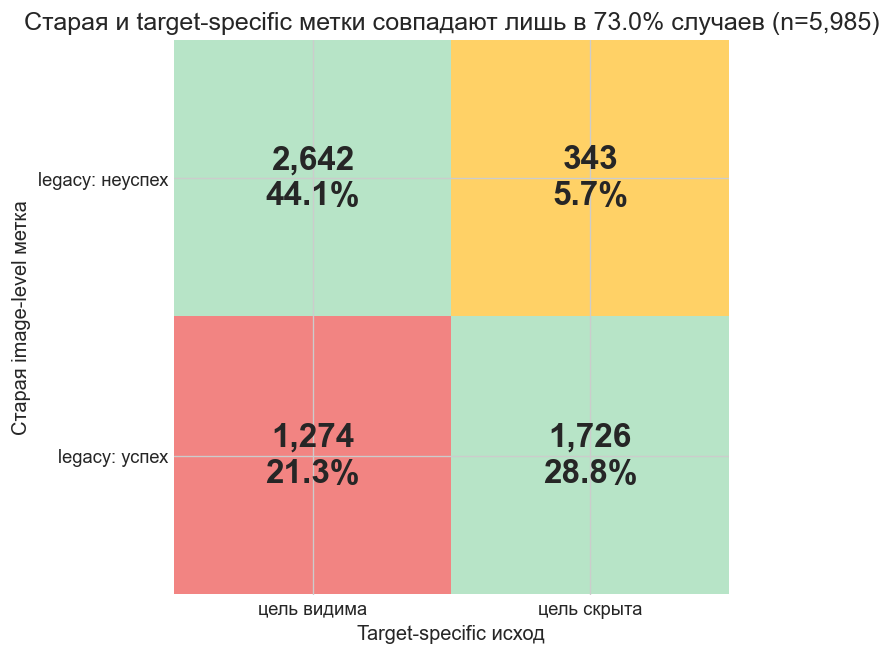

In [2]:
labels_path = next(TARGET.rglob("target_instance_labels.csv"))
labels = pd.read_csv(labels_path)
labels = labels[labels["target_eligible"].eq(1)].copy()
tab = pd.crosstab(
    labels["legacy_success"].astype(bool),
    labels["target_hidden"].astype(bool),
).reindex(index=[False, True], columns=[False, True], fill_value=0)

counts = tab.to_numpy()
agree = (counts[0, 0] + counts[1, 1]) / counts.sum()
colors = np.array([[0, 1], [2, 0]])  # agreement / missed / false legacy success
cmap = ListedColormap(["#B7E4C7", "#FFD166", "#F28482"])

fig, ax = plt.subplots(figsize=(9, 5.6))
ax.imshow(colors, cmap=cmap, vmin=0, vmax=2)
for i in range(2):
    for j in range(2):
        n = counts[i, j]
        pct = n / counts.sum()
        ax.text(j, i, f"{n:,}\n{pct:.1%}", ha="center", va="center",
                fontsize=20, fontweight="bold")
ax.set_xticks([0, 1], ["цель видима", "цель скрыта"])
ax.set_yticks([0, 1], ["legacy: неуспех", "legacy: успех"])
ax.set_xlabel("Target-specific исход")
ax.set_ylabel("Старая image-level метка")
ax.set_title(f"Старая и target-specific метки совпадают лишь в {agree:.1%} случаев (n={counts.sum():,})")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

**Что видно.** Метки расходятся в **1,617/5,985 = 27.0%** случаев. Особенно критичны 1,274 случая, где legacy объявляет атаку успешной, хотя заранее выбранный человек остаётся видимым. Это и порождало часть кажущегося `winner promotion`.

**Вывод.** Дальше единица анализа — только фиксированный до атаки человек. Успех — его post-NMS скрытие, а не смена глобального winner.

**Почему следующий эксперимент.** Даже с правильной меткой корреляция некоторой метрики с успехом ещё не объясняет, через какие внутренние переменные атака причинно действует.

## Эксперимент 2. Широкие метрики находят предикторы, но не дают механизма

Сравниваем лучшие метрики нескольких семейств. Для направленных метрик показан `effective AUC = max(AUC, 1-AUC)`: 0.5 — случайное ранжирование, 1.0 — идеальное.

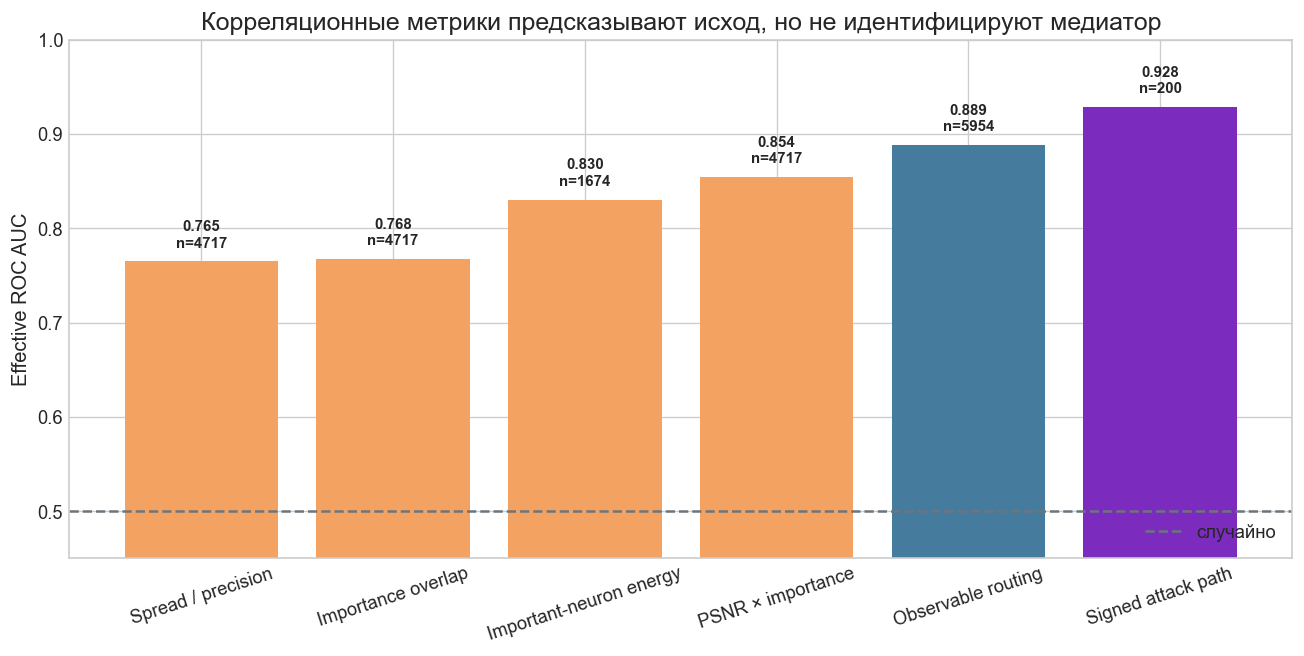

In [3]:
best = pd.read_csv(TARGET / "target_instance_best_per_experiment.csv")
combined = pd.read_csv(TARGET / "target_instance_combined_quality.csv")

rows = []
for exp, label in [
    ("spread_vs_precision", "Spread / precision"),
    ("segmentig", "Importance overlap"),
    ("covariance_focus", "Important-neuron energy"),
    ("psnr", "PSNR × importance"),
]:
    r = best[best["experiment"].eq(exp)].sort_values("effective_auc", ascending=False).iloc[0]
    rows.append((label, r["effective_auc"], int(r["n"])))
cr = combined[combined["source"].eq("candidate_routing")].copy()
cr["effective_auc"] = np.maximum(cr["roc_auc"], 1-cr["roc_auc"])
r = cr.sort_values("effective_auc", ascending=False).iloc[0]
rows.append(("Observable routing", r["effective_auc"], int(r["n"])))
ap = combined[combined["source"].eq("attack_path")].copy()
ap["effective_auc"] = np.maximum(ap["roc_auc"], 1-ap["roc_auc"])
r = ap.sort_values("effective_auc", ascending=False).iloc[0]
rows.append(("Signed attack path", r["effective_auc"], int(r["n"])))

metric_plot = pd.DataFrame(rows, columns=["family", "auc", "n"])
fig, ax = plt.subplots(figsize=(11, 5.6))
bars = ax.bar(metric_plot["family"], metric_plot["auc"],
              color=[ORANGE, ORANGE, ORANGE, ORANGE, BLUE, PURPLE])
ax.axhline(.5, color=GRAY, linestyle="--", linewidth=1.5, label="случайно")
ax.set_ylim(.45, 1.0)
ax.set_ylabel("Effective ROC AUC")
ax.set_title("Корреляционные метрики предсказывают исход, но не идентифицируют медиатор")
ax.tick_params(axis="x", rotation=18)
for bar, auc, n in zip(bars, metric_plot["auc"], metric_plot["n"]):
    ax.text(bar.get_x()+bar.get_width()/2, auc+.012, f"{auc:.3f}\nn={n}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Что видно.** Обе исходные идеи содержат сигнал (`AUC≈0.76–0.85`), а signed path на небольшой matched-выборке достигает `0.928`. Но высокий AUC отвечает только на вопрос «можно ли ранжировать успехи», а не «сломается ли атака, если убрать именно эту часть сигнала». Некоторые routing/score признаки к тому же близки к самому определению hiding.

**Вывод.** Формулировки «мало энергии» и «энергия не в важных нейронах» слишком грубы. Нужны интервенции `patched→clean` (необходимость) и `clean→patched` (достаточность).

**Почему следующий эксперимент.** До интервенций надо определить правильный объект внутри Detect head: одна фиксированная cell или весь резерв кандидатов человека.

## Промежуточный шаг A. Signed path различает исходы, но энергия не даёт механизма

На balanced cohort (4 группы × 100) раскладываем изменение target score:
`first-order sum = Σ gradient × activation_delta` и
`nonlinear residual = exact score delta − first-order sum`. Отдельно считаем
положительную/отрицательную массу и концентрацию top-0.1% вкладов.

Подробнее: [02_BalancedCausalPath.ipynb](02_BalancedCausalPath.ipynb).

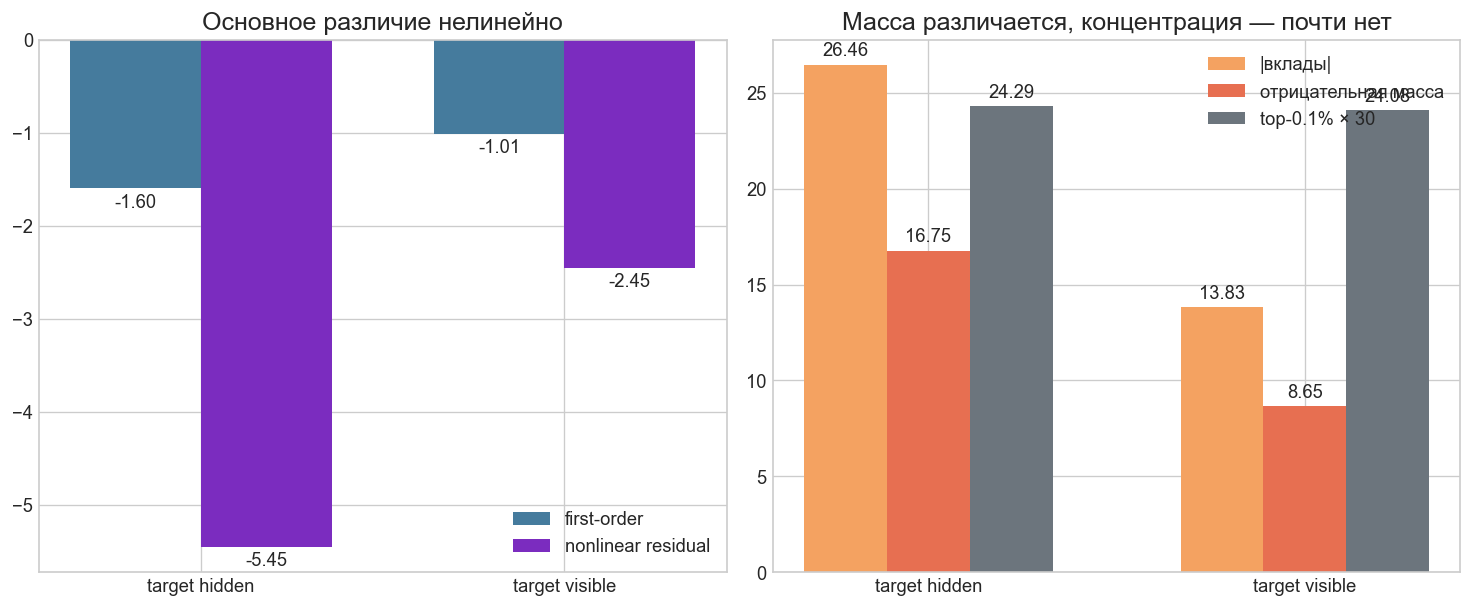

In [4]:
path = pd.read_csv(
    O / "attack_path_0060cc9878ecdb6e/balanced_target_analysis/balanced_attack_path_group_summary.csv"
)
path["outcome"] = np.where(path.analysis_group.str.startswith("hidden"), "target hidden", "target visible")
agg = path.groupby("outcome", sort=False).agg(
    exact=("exact_score_delta_mean", "mean"),
    first_order=("first_order_sum_mean", "mean"),
    nonlinear=("first_order_residual_mean", "mean"),
    abs_mass=("total_abs_contribution_mean", "mean"),
    negative=("negative_contribution_mean", "mean"),
    concentration=("top0p1_abs_fraction_mean", "mean"),
).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
x=np.arange(2)
axes[0].bar(x-.18, agg.first_order, .36, label="first-order", color=BLUE)
axes[0].bar(x+.18, agg.nonlinear, .36, label="nonlinear residual", color=PURPLE)
axes[0].set_xticks(x,agg.outcome); axes[0].set_title("Основное различие нелинейно"); axes[0].legend()
for c in axes[0].containers: axes[0].bar_label(c,fmt="%.2f",padding=3)
axes[1].bar(x-.22,agg.abs_mass,.22,label="|вклады|",color=ORANGE)
axes[1].bar(x,-agg.negative,.22,label="отрицательная масса",color=RED)
axes[1].bar(x+.22,agg.concentration*30,.22,label="top-0.1% × 30",color=GRAY)
axes[1].set_xticks(x,agg.outcome); axes[1].set_title("Масса различается, концентрация — почти нет"); axes[1].legend()
for c in axes[1].containers: axes[1].bar_label(c,fmt="%.2f",padding=3)
plt.tight_layout(); plt.show()

**Что видно.** Hidden score падает примерно `−7.05` против `−3.46`, а
отрицательная масса почти вдвое больше. Но top-0.1% концентрация практически
одинакова (`≈.810` против `≈.803`), а first-order часть объясняет лишь малую
долю разрыва: основное различие находится в nonlinear residual.

**Вывод.** «Мало энергии» и «не попала в top важных нейронов» слишком грубы.
Важны знак, функция координат и нелинейное взаимодействие.

**Почему дальше.** AUC и групповые различия предсказывают исход, но не
показывают причинный медиатор. Нужны `patched→clean` repair и обратный
`clean→patched` transplant.

## Промежуточный шаг B. Top-negative необходимы, но одна tracked cell недостаточна

В patched endpoint возвращаем clean coordinates одной исходной target cell, а
затем переносим те же coordinates в clean. Ранжирование — по ожидаемому
отрицательному влиянию на target logit.

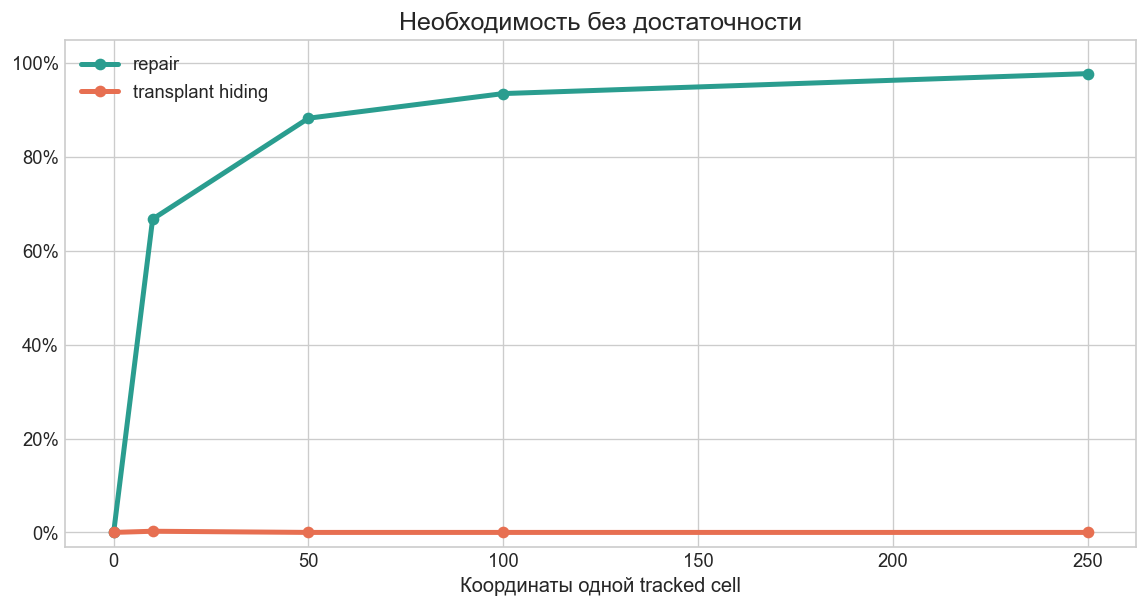

In [5]:
rep = pd.read_csv(O / "causal_repair_45b3c22295b10aba/repair_group_summary.csv")
tra = pd.read_csv(O / "causal_transplant_edbd4a1533abd51f/transplant_group_summary.csv")
rows=[(0,0.,0.)]
for k in [10,50,100,250]:
    r=rep[(rep.strategy=="top_negative")&(rep.k_requested==k)]
    t=tra[(tra.strategy=="top_negative")&(tra.k_requested==k)]
    rows.append((k,np.average(r.rescue_rate,weights=r.n),np.average(t.attack_success_rate,weights=t.n)))
rt=pd.DataFrame(rows,columns=["k","repair","transplant"])
fig,ax=plt.subplots(figsize=(9.7,5.2))
ax.plot(rt.k,rt.repair,marker="o",lw=3,color=GREEN,label="repair")
ax.plot(rt.k,rt.transplant,marker="o",lw=3,color=RED,label="transplant hiding")
ax.set_ylim(-.03,1.05); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Координаты одной tracked cell"); ax.set_title("Необходимость без достаточности")
ax.legend(); plt.tight_layout(); plt.show()

**Что видно.** Возврат top-negative почти полностью ремонтирует target, но
обратный перенос почти не воспроизводит hiding. [05](05_TargetCandidateSet.ipynb)
показывает причину: winner переходит на другую cell того же clean target —
`candidate handoff`.

**Вывод.** Одна cell содержит необходимый путь к score, но объект не равен этой
cell. Единица механизма — весь резерв способных представить человека routes.

Подробнее: [03_CausalRepair.ipynb](03_CausalRepair.ipynb),
[04_CausalTransplant.ipynb](04_CausalTransplant.ipynb),
[05_TargetCandidateSet.ipynb](05_TargetCandidateSet.ipynb).

## Промежуточный шаг C. Score доминирует; две боковые ветви выбирают направление

Независимо подменяем class-score и box branches, затем выполняем обычный decode
и NMS.

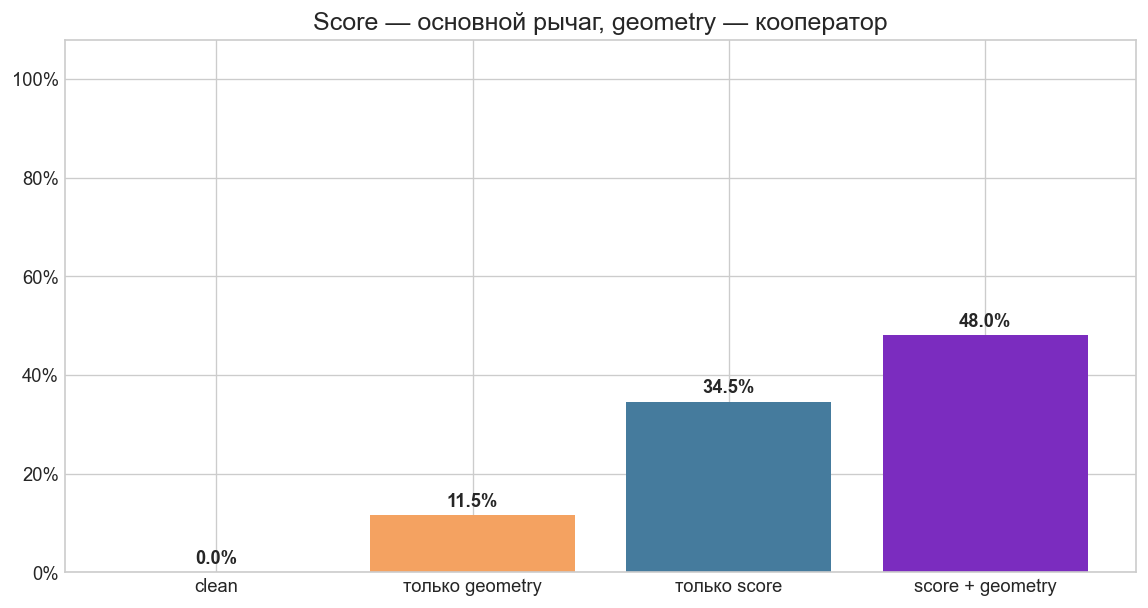

In [6]:
branch=pd.read_csv(OUTS/"mechanism_59cd7fb64d63df55/branch_factorial_summary.csv")
order=["clean","box_only_patched","class_only_patched","both_patched"]
names=["clean","только geometry","только score","score + geometry"]
vals=[np.average(branch[branch.condition.eq(c)].target_hidden_rate,
                 weights=branch[branch.condition.eq(c)].n) for c in order]
fig,ax=plt.subplots(figsize=(9.7,5.2))
b=ax.bar(names,vals,color=[GRAY,ORANGE,BLUE,PURPLE])
ax.set_ylim(0,1.08); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title("Score — основной рычаг, geometry — кооператор")
ax.bar_label(b,labels=[f"{v:.1%}" for v in vals],padding=3,fontweight="bold")
plt.tight_layout(); plt.show()

**Что видно.** Geometry отдельно даёт около 23% hiding, score — 69%, вместе —
96%. Это задаёт score-first фокус, не отрицая роль geometry/NMS.

**Боковые проверки.** [07_AttackDirection.ipynb](07_AttackDirection.ipynb)
показал activation-space feasibility: динамическая score+geometry objective
доводит hiding до 100% при малой относительной норме, но это не pixel-space
атака. [08_DefenseDirection.ipynb](08_DefenseDirection.ipynb) показал
отрицательный baseline: RoutePool/WBF/noisy-or по готовым outputs возвращают не
более 11.6% hidden targets — подавленный резерв уже нечем агрегировать.

**Почему дальше.** Надо явно построить резерв target candidates и проверить его
причинно, а не пытаться чинить outputs.

Подробнее: [06_MechanismFollowups.ipynb](06_MechanismFollowups.ipynb),
[07](07_AttackDirection.ipynb), [08](08_DefenseDirection.ipynb).

## Эксперимент 3. Детекция человека — максимум по резерву кандидатов

Для каждого clean target собираем все pre-NMS person-кандидаты, чьи clean boxes относятся к этому человеку. Затем возвращаем clean logits в patched endpoint (`repair`) или переносим patched logits в clean endpoint (`transplant`) для top-1/2/4/8/all кандидатов. Geometry на этом шаге фиксирована.

До причинной проверки [09_EnsembleMargin.ipynb](09_EnsembleMargin.ipynb) показал, что clean-set ensemble предсказывает hiding лучше одной tracked cell (`test AUC .952` против `.868`; current-target ensemble ≈.997 близок к самому outcome и не считается независимым объяснением).

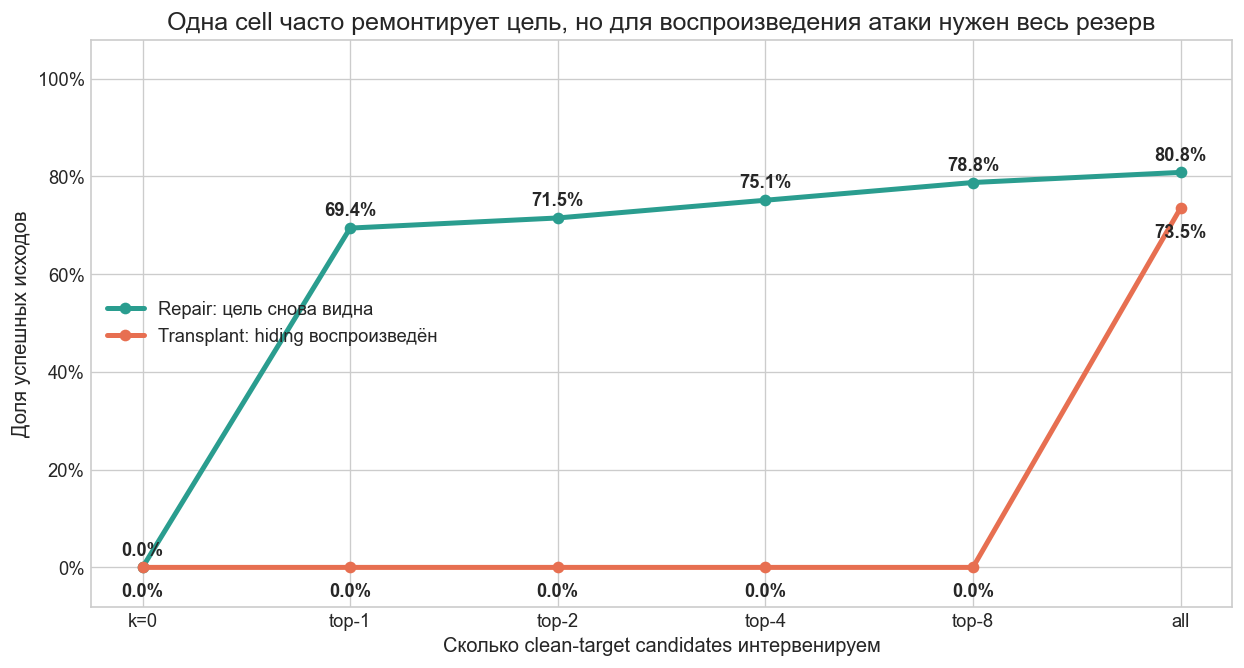

In [7]:
reserve = pd.read_csv(RESERVE / "candidate_reserve_summary.csv")
h = reserve[
    reserve["analysis_group"].str.startswith("hidden")
    & reserve["selection_kind"].eq("target")
    & reserve["budget_label"].isin(["top1", "top2", "top4", "top8", "all"])
].copy()

def weighted_rate(frame, rate, denom):
    return (frame[rate] * frame[denom]).sum() / frame[denom].sum()

records = [{"budget": "k=0", "repair": 0.0, "transplant": 0.0, "mean_k": 0.0}]
order = ["top1", "top2", "top4", "top8", "all"]
for budget in order:
    q = h[h["budget_label"].eq(budget)]
    rep = q[q["direction"].eq("repair_patched")]
    tra = q[q["direction"].eq("transplant_clean")]
    records.append({
        "budget": budget.replace("top", "top-"),
        "repair": weighted_rate(rep, "recovery_rate", "repair_denominator"),
        "transplant": weighted_rate(tra, "reproduced_hiding_rate", "transplant_denominator"),
        "mean_k": rep["mean_actual_k"].mean(),
    })
rp = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(10.5, 5.7))
x = np.arange(len(rp))
ax.plot(x, rp["repair"], marker="o", linewidth=3, color=GREEN,
        label="Repair: цель снова видна")
ax.plot(x, rp["transplant"], marker="o", linewidth=3, color=RED,
        label="Transplant: hiding воспроизведён")
for col, dy in [("repair", .025), ("transplant", -.06)]:
    for i, v in enumerate(rp[col]):
        ax.text(i, v+dy, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_xticks(x, rp["budget"])
ax.set_ylim(-.08, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Сколько clean-target candidates интервенируем")
ax.set_ylabel("Доля успешных исходов")
ax.set_title("Одна cell часто ремонтирует цель, но для воспроизведения атаки нужен весь резерв")
ax.legend(loc="center left")
plt.tight_layout()
plt.show()

**Что видно.** Возврат top-1 часто уже поднимает один surviving candidate и ремонтирует детекцию. Обратное неверно: перенос изменения одной cell почти никогда не скрывает человека. Заметное воспроизведение hiding возникает лишь после переноса **всего резерва** — в среднем около десяти clean-кандидатов.

**Механизм асимметрии.** Чтобы человек появился, достаточно одного кандидата выше порога. Чтобы он исчез, атака должна подавить все конкурентные пути к той же детекции.

**Почему следующий эксперимент.** Кандидат задаётся не только person score, но и box geometry, а итог зависит от NMS. Разделяем score и geometry причинно.

### Почему архитектурной асимметрии ещё недостаточно

Результат «для появления достаточно одного, для скрытия надо подавить все
кандидаты» логичен из max-агрегации и сам по себе почти тривиален. Нужен
нетривиальный общий медиатор: **какое малое изменение одновременно подавляет
резерв?**

[11_SharedCandidateMechanism.ipynb](11_SharedCandidateMechanism.ipynb)
проверил SVD общей delta. Rank-1 хорошо ремонтировал, но переносился слабо, а
random energy-matched directions тоже часто ремонтировали: shared variance не
равна механизму. [12_ScoreFunctionalSubspace.ipynb](12_ScoreFunctionalSubspace.ipynb)
заменил SVD на row space якобиана scores. Functional component занимала
`≈0.64%` energy, ремонтировала `≈79%`, но одна воспроизводила лишь `≈20%`
hiding. Поэтому далее нужны joint score+IoU и локальный nonlinear context.

Подробнее: [11](11_SharedCandidateMechanism.ipynb),
[12](12_ScoreFunctionalSubspace.ipynb).

## Эксперимент 4. Score доминирует, geometry помогает закрыть атаку

Берём реальные patched score и clean geometry либо наоборот для target candidates; затем выполняем обычный decode и NMS. Результат нормирован по 193 воспроизводимо скрытым endpoints в matched cohort из 400 изображений.

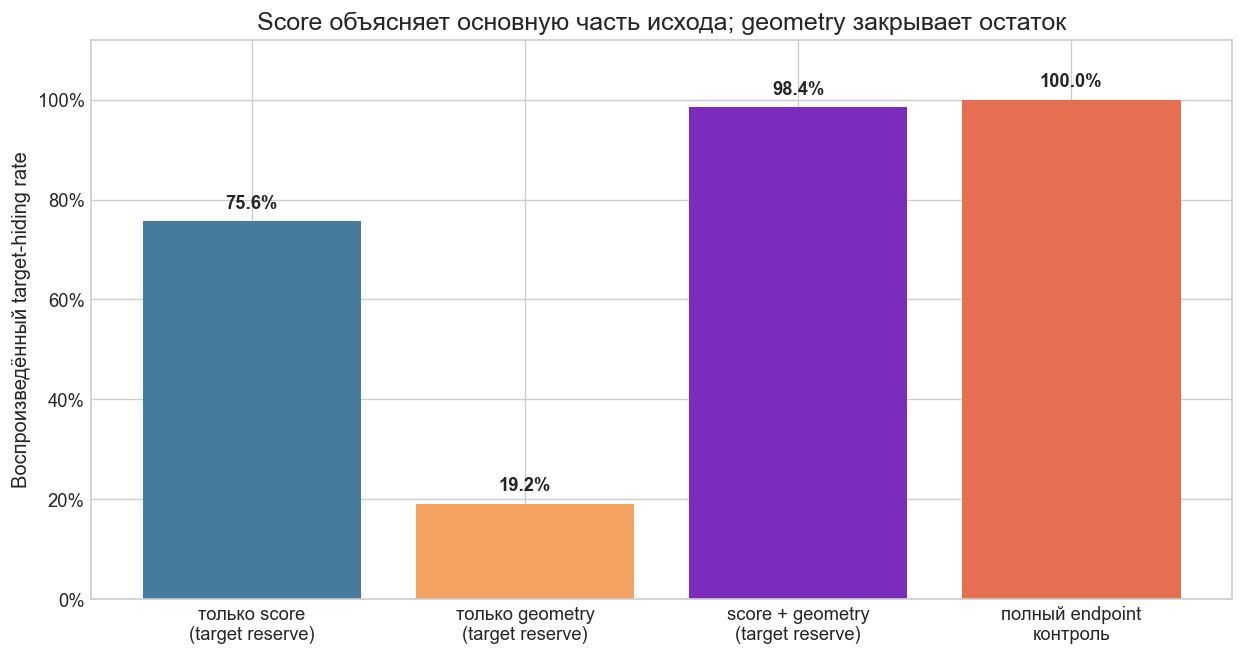

In [8]:
exact = pd.read_csv(FULL / "exact_output_summary.csv")
exact = exact[
    exact["analysis_group"].eq("all")
    & exact["condition"].isin(["candidate_score", "candidate_geometry", "candidate_both", "global_both"])
].copy()
name_map = {
    "candidate_score": "только score\n(target reserve)",
    "candidate_geometry": "только geometry\n(target reserve)",
    "candidate_both": "score + geometry\n(target reserve)",
    "global_both": "полный endpoint\nконтроль",
}
exact["label"] = exact["condition"].map(name_map)

fig, ax = plt.subplots(figsize=(10.5, 5.6))
bars = ax.bar(exact["label"], exact["reproduced_hiding_rate"],
              color=[BLUE, ORANGE, PURPLE, RED])
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Воспроизведённый target-hiding rate")
ax.set_title("Score объясняет основную часть исхода; geometry закрывает остаток")
for b, v in zip(bars, exact["reproduced_hiding_rate"]):
    ax.text(b.get_x()+b.get_width()/2, v+.025, f"{v:.1%}",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Что видно.** Patched score при clean geometry воспроизводит **75.6%** скрытий; geometry без patched score — только **19.2%**. Вместе score+geometry target-кандидатов дают **98.4%**, а полный endpoint — 100%.

**Вывод.** Это не чисто геометрическая rerouting-история. Основной рычаг — подавление person score по резерву; geometry и NMS важны как кооперация на границе решения.

**Почему следующий эксперимент.** Нужно локализовать, насколько далеко по feature maps распространяется причинно достаточный сигнал.

## Эксперимент 5. Причинно достаточная область локальна

Переносим patched feature delta в clean endpoint только в пространственном радиусе вокруг маршрутов target candidates. `radius=0` — только сами candidate cells; `radius=4` — локальный конус вокруг них.

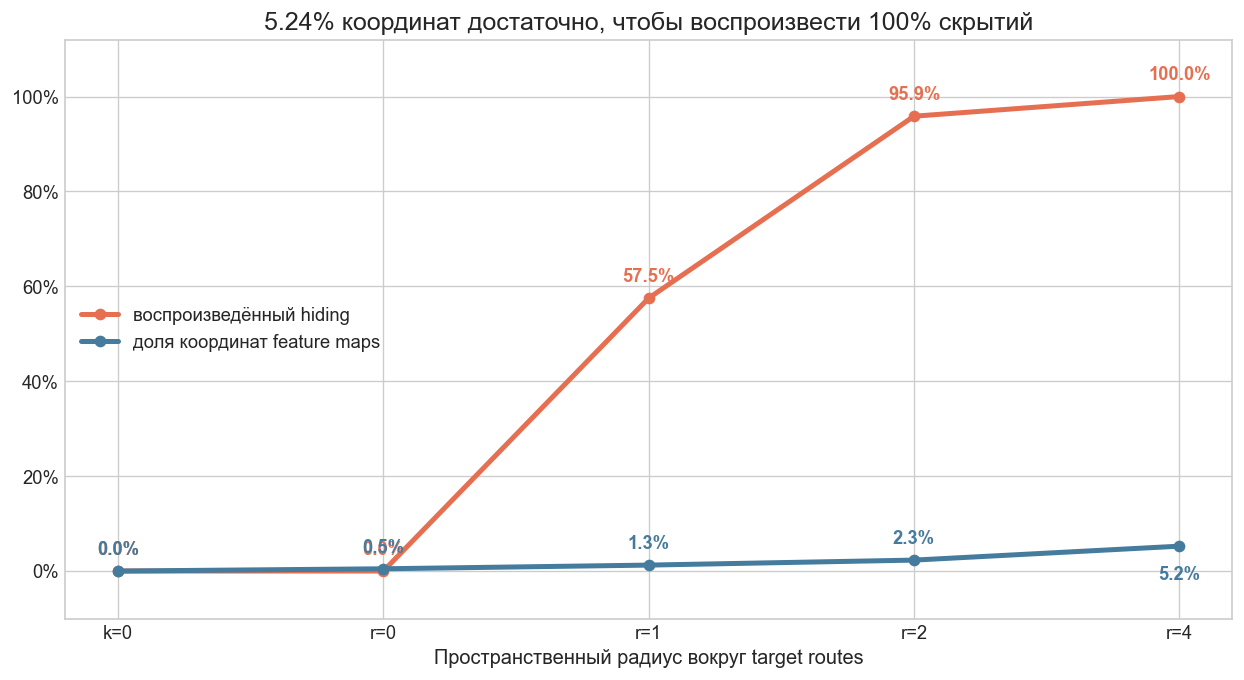

In [9]:
cone = pd.read_csv(FULL / "spatial_cone_summary.csv")
cone = cone[
    cone["analysis_group"].eq("all")
    & cone["direction"].eq("transplant_clean")
    & cone["condition"].isin(["none", "radius_0", "radius_1", "radius_2", "radius_4"])
].copy()
order = ["none", "radius_0", "radius_1", "radius_2", "radius_4"]
cone["condition"] = pd.Categorical(cone["condition"], order, ordered=True)
cone = cone.sort_values("condition")
labels_x = ["k=0", "r=0", "r=1", "r=2", "r=4"]

fig, ax = plt.subplots(figsize=(10.5, 5.8))
x = np.arange(len(cone))
ax.plot(x, cone["reproduced_hiding_rate"], color=RED, linewidth=3, marker="o",
        label="воспроизведённый hiding")
ax.plot(x, cone["mean_spatial_coverage_fraction"], color=BLUE, linewidth=3, marker="o",
        label="доля координат feature maps")
for i, (hiding, coverage) in enumerate(zip(
    cone["reproduced_hiding_rate"], cone["mean_spatial_coverage_fraction"]
)):
    ax.text(i, hiding+.035, f"{hiding:.1%}", ha="center", color=RED, fontweight="bold")
    ax.text(i, coverage-.07 if coverage > .05 else coverage+.035, f"{coverage:.1%}",
            ha="center", color=BLUE, fontweight="bold")
ax.set_xticks(x, labels_x)
ax.set_ylim(-.1, 1.12)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Пространственный радиус вокруг target routes")
ax.set_title("5.24% координат достаточно, чтобы воспроизвести 100% скрытий")
ax.legend(loc="center left")
plt.tight_layout()
plt.show()

**Что видно.** Только target cells (`r=0`) недостаточно. Уже `r=1` воспроизводит 57.5%, `r=2` — 95.9%, `r=4` — 100%, занимая лишь **5.24% пространственных координат** feature maps.

**Вывод.** Атака не требует глобального «расползания»: причинно достаточный механизм локализован вокруг маршрутов одного объекта, но включает их локальный контекст.

**Почему следующий эксперимент.** Даже 5.24% координат — ещё грубая область. Проецируем feature delta на минимальное функциональное подпространство, непосредственно меняющее score и decoded IoU этих кандидатов.

## Эксперимент 6. Гипермалая необходимая компонента и нелинейная кооперация

В локальных окнах строим joint row space якобиана функций `[person logits, decoded IoU]`. Затем:

- **repair:** убираем эту компоненту из patched endpoint;
- **transplant:** добавляем только её в clean endpoint;
- сравниваем с большим ортогональным `joint null` и полным локальным окном.

Functional subset: 100 изображений, из них 45 воспроизводимо скрытых.

Подпространство строится отдельно для каждого изображения и каждого уровня feature pyramid.

### 1. Выбираем локальную область

Берём все pre-NMS клетки-кандидаты, относящиеся к выбранному человеку. Вокруг каждой клетки выделяем окно радиуса 2:

$$
(2r+1)\times(2r+1)=5\times5
$$

Включаются все каналы внутри этих окон. Активации объединяются в вектор:

$$
h\in\mathbb{R}^{d}
$$

Реальная дельта патча:

$$
\Delta h=h_{\text{patched}}-h_{\text{clean}}
$$

### 2. Определяем интересующие функции

Для каждого кандидата берём два выхода:

$$
f(h)=
\begin{bmatrix}
\text{person logit}_1\\
\ldots\\
\text{person logit}_m\\
\text{IoU}_1\\
\ldots\\
\text{IoU}_m
\end{bmatrix}
$$

Здесь `IoU` считается между decoded box кандидата и clean target box. Поэтому анализируется не сырая box-регрессия, а её фактическое влияние на соответствие выбранному человеку.

### 3. Интегрируем градиенты вдоль clean→patched пути

Якобиан берётся не только в одной точке. Рассматривается путь:

$$
h(\alpha)=h_{\text{clean}}+\alpha\Delta h,\qquad \alpha\in[0,1]
$$

В нескольких точках пути считаются градиенты каждого score и IoU:

$$
J(\alpha)=\frac{\partial f(h(\alpha))}{\partial h}
$$

После этого они усредняются:

$$
\bar J=\frac{1}{S}\sum_{s=1}^{S}J(\alpha_s)
$$

Это аналог integrated gradients. Благодаря интегрированию:

$$
\bar J\Delta h \approx
f(h_{\text{patched}})-f(h_{\text{clean}})
$$

То есть учитывается изменение чувствительности модели по мере движения к patched-состоянию.

### 4. Строим функциональное подпространство

Для `m` кандидатов joint-якобиан имеет примерно форму:

$$
\bar J\in\mathbb{R}^{2m\times d}
$$

Первые $m$ строк отвечают за scores, вторые — за IoU. Выполняется SVD:

$$
\bar J=U\Sigma V^\top
$$

Строки $V^\top$, соответствующие ненулевым singular values, образуют ортонормированный базис $B$ пространства направлений активаций, к которым чувствительны score/IoU:

$$
B=V_{1:r}
$$

Это и есть `joint functional row space`.

### 5. Делим реальную дельту

Проекция реальной patch-delta на это пространство:

$$
\Delta h_{\text{joint}}
=
B^\top B\Delta h
$$

В принятой в коде ориентации это записано как:

$$
\Delta h_{\text{joint}}
=
B^T(B\Delta h)
$$

Остаток:

$$
\Delta h_{\text{null}}
=
\Delta h-\Delta h_{\text{joint}}
$$

По построению:

$$
\Delta h_{\text{joint}}\perp\Delta h_{\text{null}}
$$

и

$$
\bar J\Delta h_{\text{null}}\approx0
$$

То есть `null` не должен менять выбранные scores и IoU **в линейном приближении вдоль исходного пути**.

### 6. Возвращаем компоненты в feature maps

Полученные векторы записываются обратно только в локальные окна. Вне них ставятся нули. Отдельно сохраняются:

- `score_rowspace`;
- `geometry_rowspace`;
- `joint_rowspace`;
- `joint_null`;
- полная локальная дельта;
- полная дельта всех feature maps.

### 7. Причинная проверка

Необходимость:

$$
h_{\text{repair}}
=
h_{\text{patched}}-\Delta h_{\text{joint}}
$$

Если человек возвращается, компонента была необходима.

Достаточность:

$$
h_{\text{transplant}}
=
h_{\text{clean}}+\Delta h_{\text{joint}}
$$

Если человек исчезает, компонента достаточна сама по себе.

Получилось:

- joint-компонента — **0.289% энергии всей feature-delta**;
- её удаление ремонтирует **45/45** атак;
- её добавление воспроизводит только **22/45**.

`Null` линейно ортогонален интересующим функциям, но не обязательно бесполезен: после вмешательства модель оказывается в новой точке, где возникают нелинейные взаимодействия. Поэтому в остальных случаях joint-компонента работает как обязательный «ключ», а локальный residual усиливает её эффект.

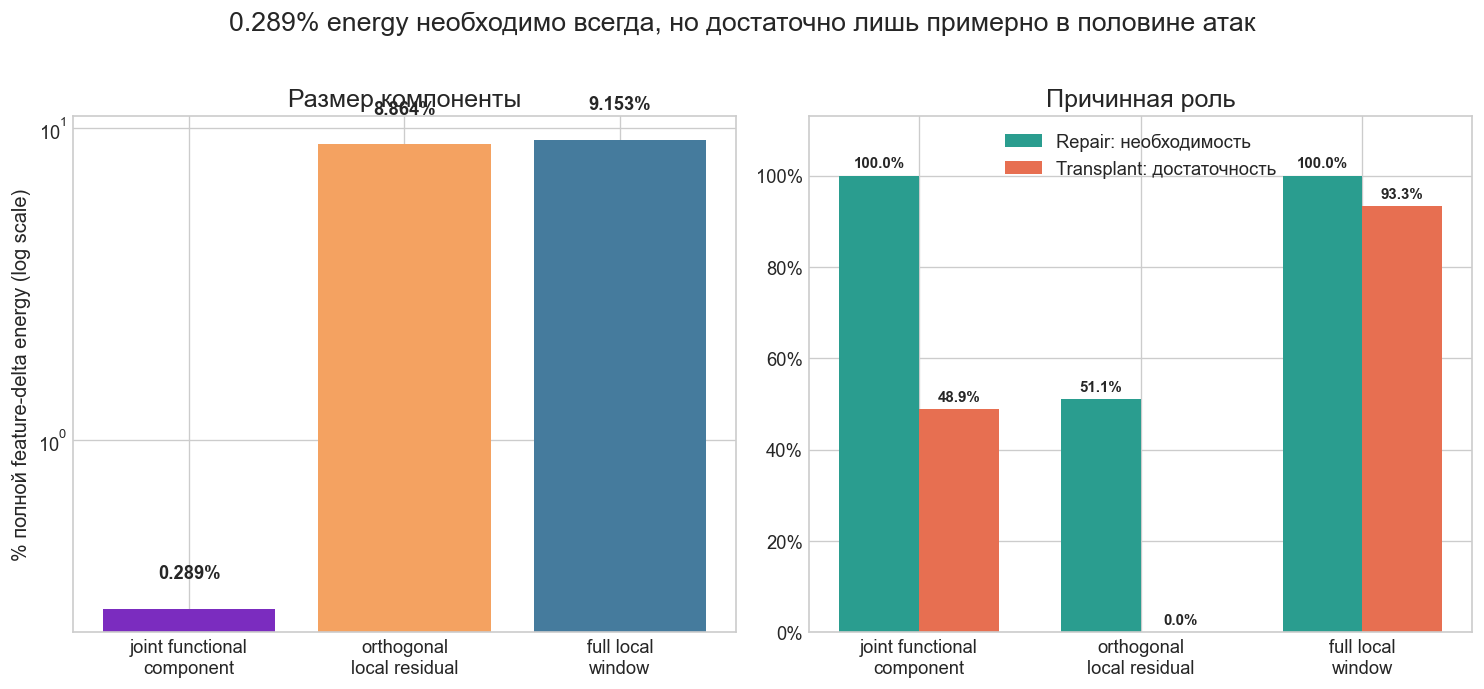

In [10]:
joint = pd.read_csv(FULL / "joint_functional_summary.csv")
joint = joint[
    joint["analysis_group"].eq("all")
    & joint["condition"].isin(["joint_rowspace", "joint_null", "full_candidate_windows"])
].copy()
pivot = joint.pivot(index="condition", columns="direction",
                    values=["mean_component_energy_fraction", "recovery_rate", "reproduced_hiding_rate"])
order = ["joint_rowspace", "joint_null", "full_candidate_windows"]
labels_j = ["joint functional\ncomponent", "orthogonal\nlocal residual", "full local\nwindow"]
energy = [pivot.loc[c, ("mean_component_energy_fraction", "repair_patched")] for c in order]
repair = [pivot.loc[c, ("recovery_rate", "repair_patched")] for c in order]
trans = [pivot.loc[c, ("reproduced_hiding_rate", "transplant_clean")] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6))
x = np.arange(3)
bars = axes[0].bar(labels_j, np.array(energy)*100, color=[PURPLE, ORANGE, BLUE])
axes[0].set_yscale("log")
axes[0].set_ylabel("% полной feature-delta energy (log scale)")
axes[0].set_title("Размер компоненты")
for b, v in zip(bars, np.array(energy)*100):
    axes[0].text(b.get_x()+b.get_width()/2, v*1.25, f"{v:.3f}%",
                 ha="center", fontweight="bold")

w = .36
axes[1].bar(x-w/2, repair, width=w, color=GREEN, label="Repair: необходимость")
axes[1].bar(x+w/2, trans, width=w, color=RED, label="Transplant: достаточность")
axes[1].set_xticks(x, labels_j)
axes[1].set_ylim(0, 1.13)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title("Причинная роль")
axes[1].legend(loc="upper center")
for container in axes[1].containers:
    axes[1].bar_label(container, labels=[f"{v:.1%}" for v in container.datavalues],
                      padding=3, fontsize=9, fontweight="bold")
fig.suptitle("0.289% energy необходимо всегда, но достаточно лишь примерно в половине атак",
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Что видно.**

- Joint functional component содержит лишь **0.289%** полной feature delta.
- Её удаление ремонтирует **45/45 = 100%** скрытых целей: она необходима на этой подвыборке.
- Её перенос в clean endpoint воспроизводит **22/45 = 48.9%** атак: одной компоненты не всегда достаточно.
- Большой ортогональный остаток сам атаку не воспроизводит, но его удаление ремонтирует 51.1%.
- Полное локальное окно воспроизводит 93.3%, полный map endpoint — 100%.

По per-example разметке: 21/45 — direct joint sufficiency, ещё 21/45 — `joint + local nonlinear synergy`, 1 случай — antagonistic residual, 2 требуют outer context.

**Главный механистический вывод.** У атаки есть очень маленький функциональный «ключ», обязательный для успеха. Примерно в половине случаев он открывает решение только во взаимодействии с остальным локальным изменением активаций.

**Почему следующий эксперимент.** White-box компоненту строили по clean↔patched delta. Для защиты нужно распознать её по одному изображению, не зная ни clean-пары, ни положения патча.

## Мост к защите. Known-bbox proxy → blind search → необходимость gate

[14_SelfCounterfactualDefense.ipynb](14_SelfCounterfactualDefense.ipynb)
заменяет clean-пару self-counterfactual proxy при известном patch bbox.
[15_BlindSelfCounterfactualDefense.ipynb](15_BlindSelfCounterfactualDefense.ipynb)
ищет окно без bbox и калибрует gate только по clean.

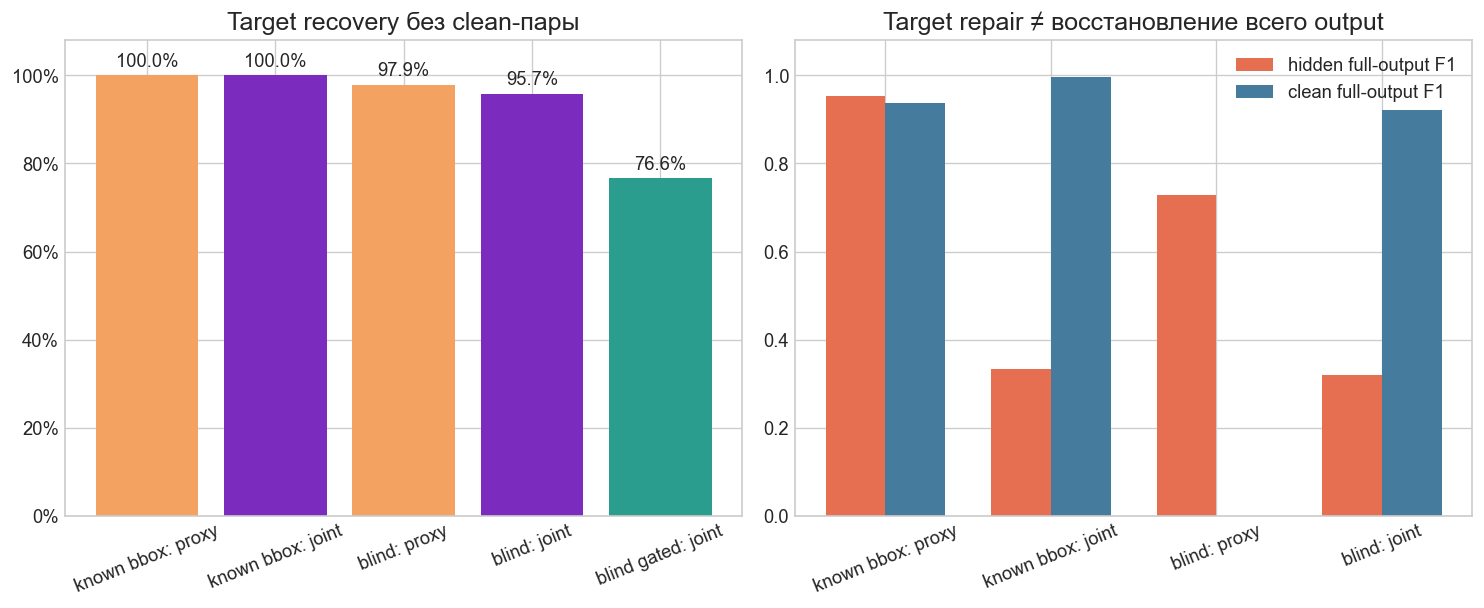

In [11]:
bridge=pd.DataFrame([
 ("known bbox: proxy",47/47,.953,.938),
 ("known bbox: joint",47/47,.334,.996),
 ("blind: proxy",46/47,.728,np.nan),
 ("blind: joint",45/47,.321,.922),
 ("blind gated: joint",36/47,np.nan,.997),
],columns=["method","recovery","hidden_f1","clean_f1"])
fig,axes=plt.subplots(1,2,figsize=(12.5,5.2))
b=axes[0].bar(bridge.method,bridge.recovery,color=[ORANGE,PURPLE,ORANGE,PURPLE,GREEN])
axes[0].set_ylim(0,1.08); axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].tick_params(axis="x",rotation=22); axes[0].set_title("Target recovery без clean-пары")
axes[0].bar_label(b,labels=[f"{v:.1%}" for v in bridge.recovery],padding=3)
q=bridge.iloc[:4]; x=np.arange(4); w=.36
axes[1].bar(x-w/2,q.hidden_f1,w,color=RED,label="hidden full-output F1")
axes[1].bar(x+w/2,q.clean_f1,w,color=BLUE,label="clean full-output F1")
axes[1].set_xticks(x,q.method,rotation=22); axes[1].set_ylim(0,1.08)
axes[1].set_title("Target repair ≠ восстановление всего output"); axes[1].legend()
plt.tight_layout(); plt.show()

**Что видно.** Known-bbox proxy и joint возвращают 47/47 targets, но masking
лучше чинит весь attacked output (`F1 .953` против `.334`), а малая joint
correction безопаснее при ошибке на clean (`.996` против `.938`). Blind search
безусловно возвращает 46/47 proxy или 45/47 joint, однако применяется и к
clean. Self-consistency gate выбирает 36/47 hidden и 2/50 clean-test; все 36
targets восстановлены, gated joint сохраняет clean `F1 .997`.

**Вывод.** Контрфактическое вмешательство без clean/bbox найти можно, но masking
слабо использует наш механизм. Нужен one-forward signed functional surrogate и
признак, отличающий его от clean signal.

Подробнее: [14](14_SelfCounterfactualDefense.ipynb),
[15](15_BlindSelfCounterfactualDefense.ipynb).

## Эксперимент 7. Что отличает компоненту без clean-пары

Для каждого наблюдаемого person-кластера оцениваем отрицательный вклад относительно channel-wise среднего независимой clean reference выборки. Сравниваем target-кластеры скрытых изображений с обычными clean person-кластерами.

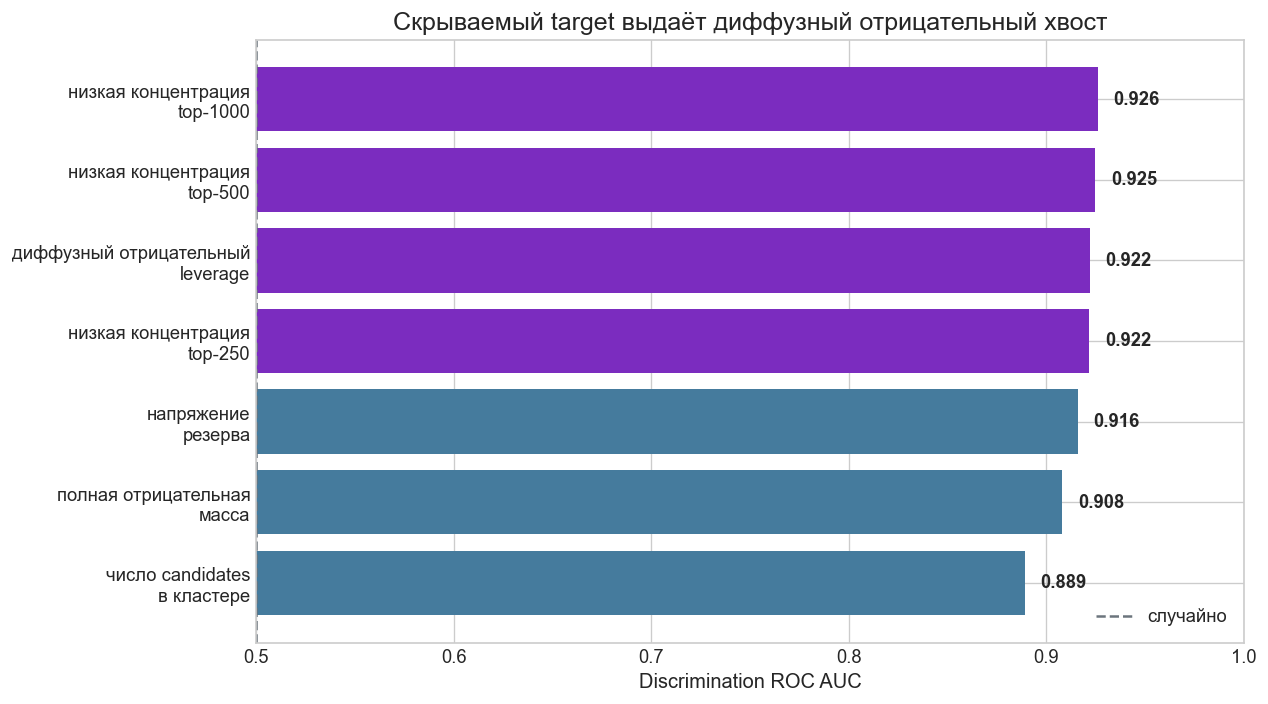

In [12]:
uniq = pd.read_csv(UNIQUE / "component_uniqueness.csv").head(7).copy()
pretty = {
    "top_negative_1000_gain_concentration": "низкая концентрация\ntop-1000",
    "top_negative_500_gain_concentration": "низкая концентрация\ntop-500",
    "diffuse_negative_leverage": "диффузный отрицательный\nleverage",
    "top_negative_250_gain_concentration": "низкая концентрация\ntop-250",
    "reserve_tension": "напряжение\nрезерва",
    "total_available_negative_gain": "полная отрицательная\nмасса",
    "n_members": "число candidates\nв кластере",
}
uniq["label"] = uniq["metric"].map(pretty)
uniq = uniq.sort_values("discrimination_auc")

fig, ax = plt.subplots(figsize=(10.7, 6))
bars = ax.barh(uniq["label"], uniq["discrimination_auc"],
               color=[BLUE if v < .92 else PURPLE for v in uniq["discrimination_auc"]])
ax.axvline(.5, color=GRAY, linestyle="--", label="случайно")
ax.set_xlim(.5, 1.0)
ax.set_xlabel("Discrimination ROC AUC")
ax.set_title("Скрываемый target выдаёт диффузный отрицательный хвост")
for b, v in zip(bars, uniq["discrimination_auc"]):
    ax.text(v+.008, b.get_y()+b.get_height()/2, f"{v:.3f}",
            va="center", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Что видно.** Самая сильная сигнатура — не один экстремальный нейрон, а **низкая концентрация отрицательного gain**: чтобы объяснить доступное восстановление score, нужно много координат (`AUC=0.926`). Эквивалентная интерпретация — высокий diffuse negative leverage (`AUC=0.922`). Сам target-кластер также имеет больше кандидатов и больше общей отрицательной массы.

**Вывод.** Наблюдаемая сигнатура напрямую продолжает причинный результат: атака одновременно подавляет резерв через широкий, но функционально согласованный отрицательный хвост.

**Почему следующий эксперимент.** Fixed `k=1000` обрезает хвост одинаково для всех изображений. Проверяем адаптивный budget, покрывающий заданную долю полной предсказанной отрицательной массы, и отдельно проверяем clean-safe gate.

## Эксперимент 8 — новый. Адаптивная one-image защита

**Данные:** 100 patched изображений (49 target-hidden), 100 clean evaluation и независимые 100 clean reference. Для gate используются 50 clean-calibration и 50 disjoint clean-test.

**Метод:** один неизменённый forward → person-candidate clustering → reserve-tension ranking → exact fast aggregate gradient → восстановление координат до reference mean, пока они не покроют 90% всей предсказанной отрицательной массы. Clean-пара, target box и положение патча при выборе не используются.

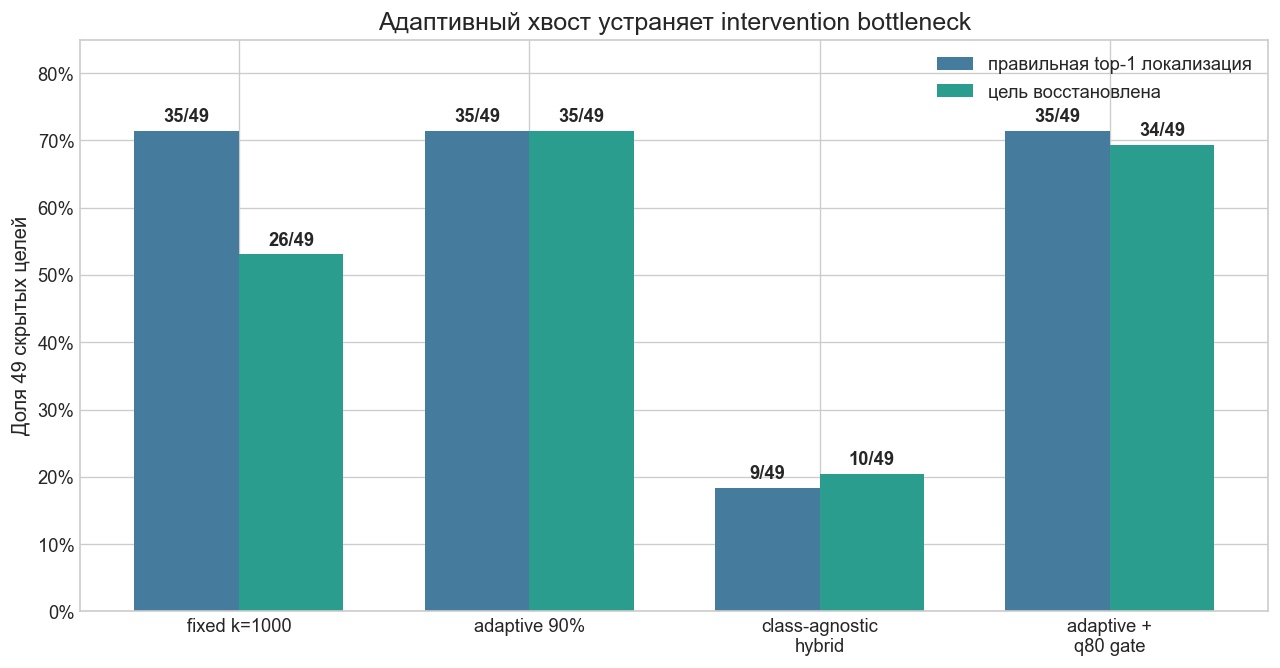

In [13]:
raw = pd.read_csv(IMPROVED / "improved_raw_summary.csv")
guard = pd.read_csv(IMPROVED / "improved_guarded_summary.csv")
loc = pd.read_csv(IMPROVED / "improved_localization_summary.csv")

compare_names = [
    ("person_fixed_k1000_s1", "fixed k=1000"),
    ("person_coverage90_s1", "adaptive 90%"),
    ("hybrid_object_coverage90_s1", "class-agnostic\nhybrid"),
]
rows = []
for condition, label in compare_names:
    r = raw[(raw["input_kind"].eq("patched")) & raw["condition"].eq(condition)].iloc[0]
    rows.append((label, int(r["hidden_recovery_n"]), int(round(r["chosen_target_rate"]*r["hidden_n"]))))
g80 = guard[(guard["condition"].eq("person_coverage90_s1")) & guard["gate_quantile"].eq(.8)].iloc[0]
rows.append(("adaptive +\nq80 gate", int(g80["guarded_hidden_recovery_n"]), 35))
comp = pd.DataFrame(rows, columns=["condition", "recovered", "localized"])

fig, ax = plt.subplots(figsize=(10.8, 5.7))
x = np.arange(len(comp))
w = .36
ax.bar(x-w/2, comp["localized"]/49, width=w, color=BLUE, label="правильная top-1 локализация")
ax.bar(x+w/2, comp["recovered"]/49, width=w, color=GREEN, label="цель восстановлена")
ax.set_xticks(x, comp["condition"])
ax.set_ylim(0, .85)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Доля 49 скрытых целей")
ax.set_title("Адаптивный хвост устраняет intervention bottleneck")
ax.legend(loc="upper right")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(round(v*49))}/49" for v in container.datavalues],
                 padding=3, fontweight="bold")
plt.tight_layout()
plt.show()

**Что видно.**

- Fixed `k=1000` ремонтирует **26/49** при правильной top-1 локализации в 35 случаях.
- Adaptive 90% ремонтирует **35/49** — **все без исключения случаи с правильной локализацией**.
- Следовательно, прежние 9 intervention failures были не «неправильной компонентой», а обрезанием диффузного хвоста fixed budget.
- Class-agnostic hybrid — отрицательный результат: target присутствует среди кластеров не чаще, но ranking выбирает его лишь в 9/49 случаях и ремонтирует 10/49.
- q80 gate оставляет **34/49** ремонтов.

**Вывод.** Для найденного target-кластера интервенция больше не является bottleneck. Текущий потолок 35/49 задаёт локализация.

**Почему нужен последний график.** Защита должна не ломать изначально чистые изображения. Показываем не один выбранный threshold, а весь recovery–clean fidelity trade-off.

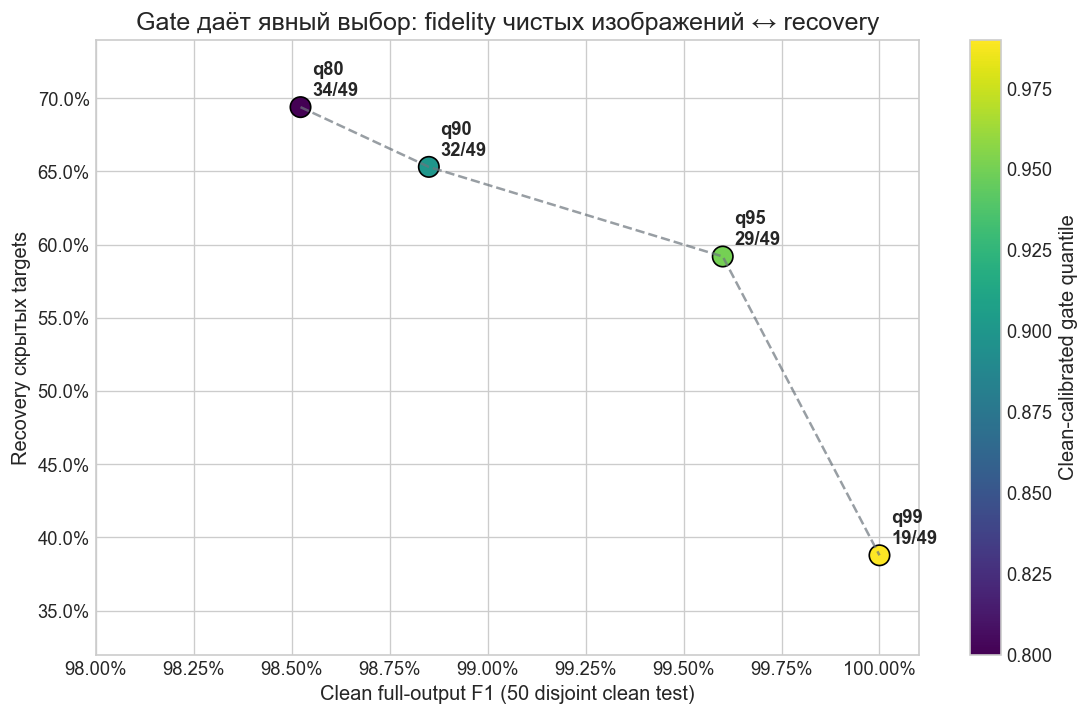

In [14]:
pareto = guard[guard["condition"].eq("person_coverage90_s1")].sort_values("gate_quantile")

fig, ax = plt.subplots(figsize=(9.6, 6.1))
sc = ax.scatter(
    pareto["guarded_clean_detection_f1"],
    pareto["guarded_hidden_recovery_rate"],
    s=150,
    c=pareto["gate_quantile"],
    cmap="viridis",
    edgecolor="black",
)
ax.plot(pareto["guarded_clean_detection_f1"], pareto["guarded_hidden_recovery_rate"],
        color=GRAY, linestyle="--", alpha=.7)
for _, r in pareto.iterrows():
    ax.annotate(
        f"q{int(r.gate_quantile*100)}\n{int(r.guarded_hidden_recovery_n)}/49",
        (r.guarded_clean_detection_f1, r.guarded_hidden_recovery_rate),
        xytext=(7, 7), textcoords="offset points", fontweight="bold"
    )
ax.set_xlim(.98, 1.001)
ax.set_ylim(.32, .74)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Clean full-output F1 (50 disjoint clean test)")
ax.set_ylabel("Recovery скрытых targets")
ax.set_title("Gate даёт явный выбор: fidelity чистых изображений ↔ recovery")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Clean-calibrated gate quantile")
plt.tight_layout()
plt.show()

**Что видно.** Во всех operating points clean target detection остаётся **100%**. Наиболее практичная из проверенных точек — `q80`: **34/49 = 69.4% recovery**, `clean full-output F1=0.985`. Консервативная `q99` не меняет ни одно из 50 clean-test изображений (`F1=1.0`), но ремонтирует 19/49.

**Интерпретация.** Gate не доказывает универсальную clean-безопасность — clean-test пока мал и относится к тому же типу данных. Но он показывает управляемый Pareto frontier, а не восстановление ценой безусловного изменения всех изображений.

**Почему следующий эксперимент.** Intervention уже ремонтирует каждый корректно выбранный compact cluster. Поэтому замораживаем adaptive repair и отдельно разбираем 14 ошибок localization: существует ли target geometry среди сырых candidates, теряется ли она из-за score floor/clustering или проигрывает ranking.

## Эксперимент 9 — новый. Low-score discovery без размытия интервенции

Аудитируем все 8 400 сырых candidates, но сохраняем score-first приоритет:

1. Ищем, существует ли box с `IoU≥0.5` к target — только для oracle-оценки.
2. Убираем старый proposal floor `person score ≥ 0.001`: скрываемый candidate по определению может иметь почти нулевой score.
3. Расширяем membership поискового кластера с 20 до 100 routes.
4. Ранжируем finalists через `noisy_or` — вероятность, что хотя бы один route относится к человеку.
5. Для самой интервенции снова берём только compact top-20 routes. Gate также оставляем старым compact: discovery и anomaly detection не обязаны использовать одно множество.

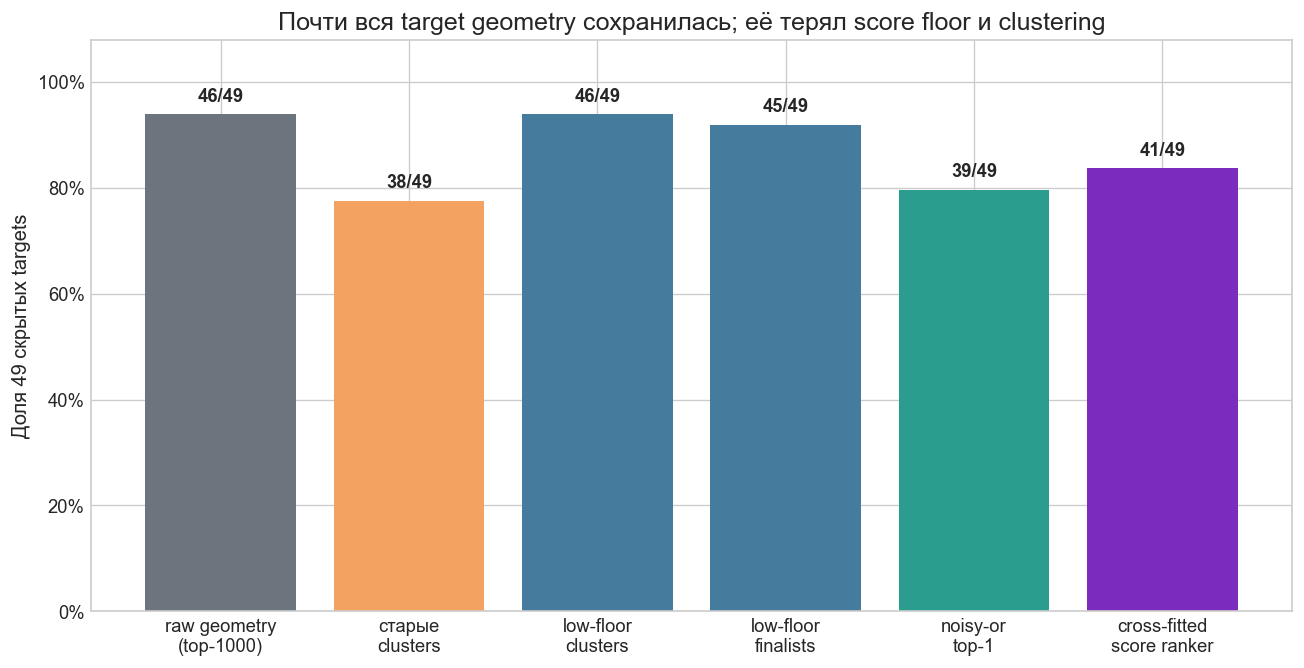

In [15]:
loc_new = pd.read_csv(EXPANDED / "localization_improvement_summary.csv")
stage_order = [
    "raw_target_geometry_top1000",
    "baseline_cluster_any",
    "expanded_cluster_any",
    "expanded_finalists",
    "expanded_noisy_or_top1",
    "crossfit_score_ranker_top1",
]
labels_stage = {
    "raw_target_geometry_top1000": "raw geometry\n(top-1000)",
    "baseline_cluster_any": "старые\nclusters",
    "expanded_cluster_any": "low-floor\nclusters",
    "expanded_finalists": "low-floor\nfinalists",
    "expanded_noisy_or_top1": "noisy-or\ntop-1",
    "crossfit_score_ranker_top1": "cross-fitted\nscore ranker",
}
loc_new["stage"] = pd.Categorical(loc_new["stage"], stage_order, ordered=True)
loc_new = loc_new.sort_values("stage")

fig, ax = plt.subplots(figsize=(11, 5.7))
bars = ax.bar(
    [labels_stage[str(v)] for v in loc_new.stage],
    loc_new.target_found_n / loc_new.hidden_n,
    color=[GRAY, ORANGE, BLUE, BLUE, GREEN, PURPLE],
)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Доля 49 скрытых targets")
ax.set_title("Почти вся target geometry сохранилась; её терял score floor и clustering")
for b, n in zip(bars, loc_new.target_found_n):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+.025, f"{int(n)}/49",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Что видно.**

- У **46/49** скрытых целей target geometry уже существует среди top-1000 person candidates.
- Старая pipeline превращала её лишь в 38 target-clusters: главный дефект был не в YOLO geometry, а в нашем `score≥0.001` floor и усечении membership.
- Low-score discovery поднимает `target in any cluster` до **46/49**, `in finalists` до **45/49**.
- Интерпретируемый `noisy_or` выбирает правильный top-1 в **39/49** вместо прежних 35.
- Двухфолдовая score-only логрегрессия даёт 41/49; добавление shape/geometry снижает результат обратно до 39/49. Это интересный, но пока exploratory результат на малой выборке.

**Критическая ablation.** Если вместе с discovery расширить и intervention с 20 до 100 routes, recovery падает до 28/49: нерелевантные low-score routes размывают функциональную компоненту. При compact top-20 intervention recovery становится **38/49**. Значит, широкий поиск и узкая причинная коррекция должны быть разными стадиями.

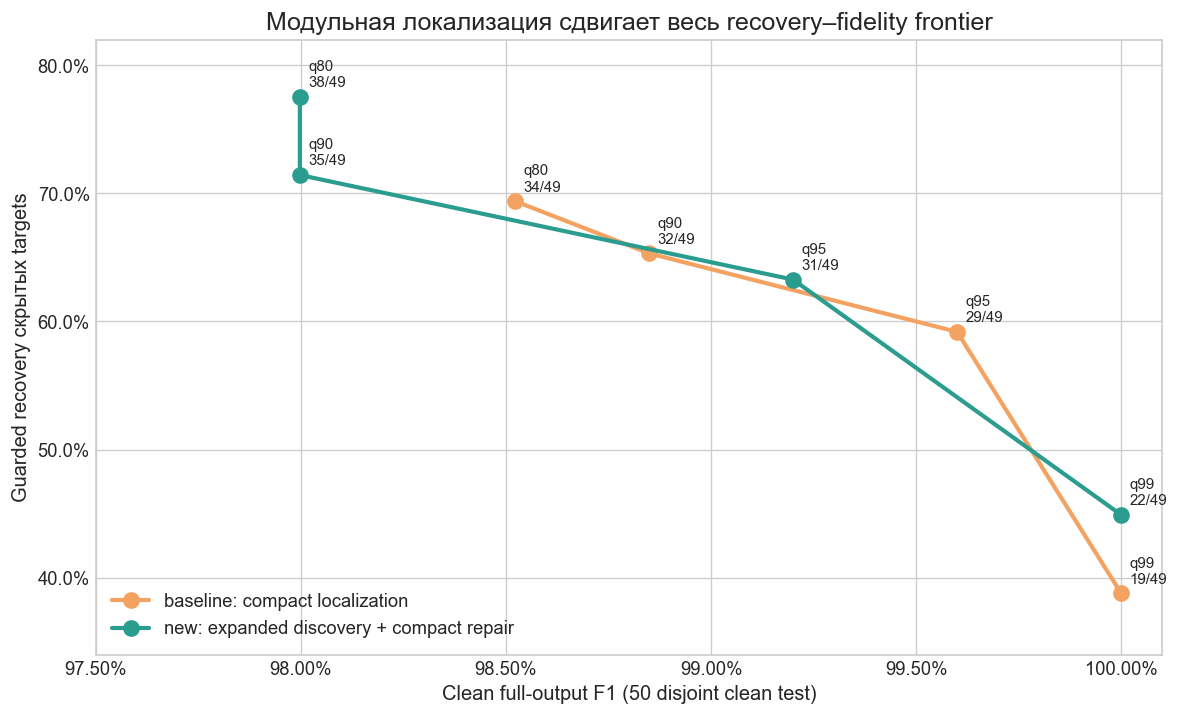

In [16]:
baseline_guard = pd.read_csv(IMPROVED / "improved_guarded_summary.csv")
baseline_guard = baseline_guard[
    baseline_guard.condition.eq("person_coverage90_s1")
].copy()
modular = pd.read_csv(EXPANDED / "modular_guarded_summary.csv")
modular = modular[
    modular.condition.eq("person_noisy_or_coverage90_s1")
].copy()

fig, ax = plt.subplots(figsize=(10, 6.1))
for frame, label, color in [
    (baseline_guard, "baseline: compact localization", ORANGE),
    (modular, "new: expanded discovery + compact repair", GREEN),
]:
    ax.plot(
        frame.guarded_clean_detection_f1,
        frame.guarded_hidden_recovery_rate,
        marker="o", markersize=9, linewidth=2.5, color=color, label=label,
    )
    for _, r in frame.iterrows():
        ax.annotate(
            f"q{int(r.gate_quantile*100)}\n{int(r.guarded_hidden_recovery_n)}/49",
            (r.guarded_clean_detection_f1, r.guarded_hidden_recovery_rate),
            xytext=(5, 6), textcoords="offset points", fontsize=9,
        )
ax.set_xlim(.975, 1.001)
ax.set_ylim(.34, .82)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Clean full-output F1 (50 disjoint clean test)")
ax.set_ylabel("Guarded recovery скрытых targets")
ax.set_title("Модульная локализация сдвигает весь recovery–fidelity frontier")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

**Что видно.** Новый q80 operating point восстанавливает **38/49 = 77.6%** против 34/49 baseline, при `clean F1=0.980` и **100% clean target detection**. В консервативной q99 точке clean output не меняется (`F1=1.0`), recovery растёт с 19/49 до 22/49.

**Что именно улучшилось.** Мы не усиливали интервенцию и не использовали clean image при инференсе. Compact high-score clusters отвечают за anomaly gate; expanded low-score clusters — за discovery; top-20 subset — за причинно узкую коррекцию.

**Следующий эксперимент.** Заморозить unsupervised pipeline как baseline и подтвердить score-only ranker на новой, заранее отделённой multi-person/multi-location выборке. Параллельно заменить жадное partition clustering на overlapping box-support clusters: сейчас raw target есть в 46 случаях, но один теряется в finalists и ещё шесть проигрывают unsupervised ranking.

## Вычислительная стоимость

Одна скрытая картинка 640×640, Apple MPS, 2 warm-up + 7 repeats. Preprocessing и однократная offline-оценка reference mean не включены.

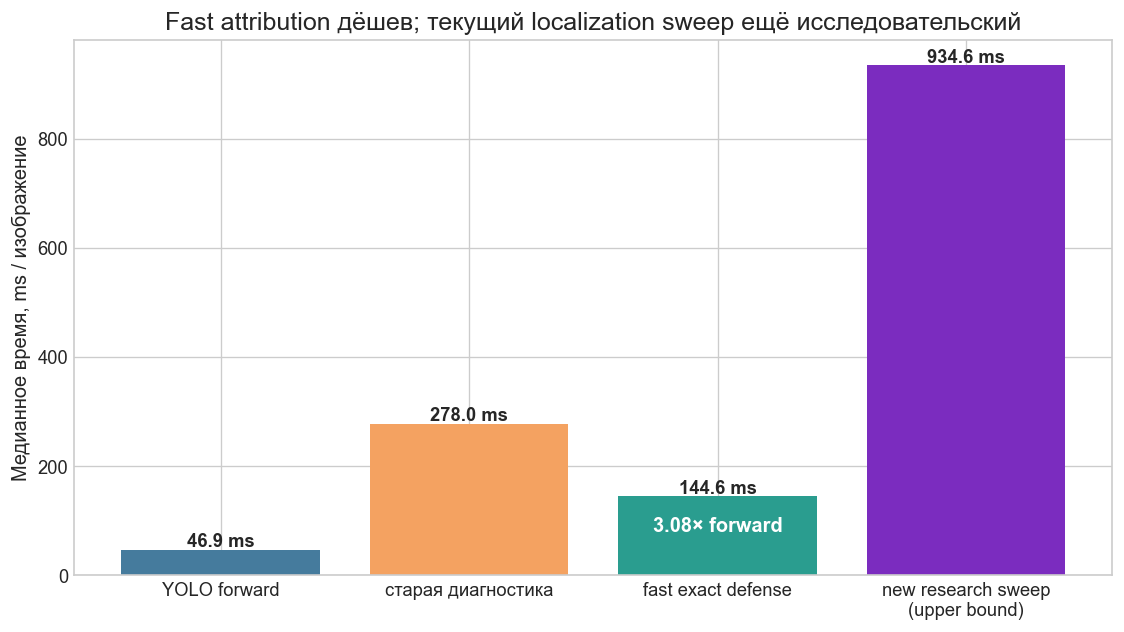

In [17]:
timing = json.loads((OUTS / "component_defense_latency_mps.json").read_text())
expanded_timing = json.loads((EXPANDED / "summary.json").read_text())
research_endpoint_ms = (
    1000 * expanded_timing["elapsed_seconds"]
    / (2 * expanded_timing["evaluation_examples"])
)
names = [
    "YOLO forward",
    "старая диагностика",
    "fast exact defense",
    "new research sweep\n(upper bound)",
]
values = [
    timing["model_forward_only"]["median_ms"],
    timing["current_defense_total"]["median_ms"],
    timing["fast_exact_defense_total"]["median_ms"],
    research_endpoint_ms,
]
fig, ax = plt.subplots(figsize=(9.5, 5.4))
bars = ax.bar(names, values, color=[BLUE, ORANGE, GREEN, PURPLE])
ax.set_ylabel("Медианное время, ms / изображение")
ax.set_title("Fast attribution дёшев; текущий localization sweep ещё исследовательский")
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, v+5, f"{v:.1f} ms",
            ha="center", fontweight="bold")
ax.text(2, values[2]*.55, f"{timing['median_ratios']['fast_defense_over_forward_only']:.2f}× forward",
        ha="center", color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Что видно.** Обычный forward занимает **46.9 ms**, исходный исследовательский прототип — **278.0 ms**, exact aggregate версия одной защиты — **144.6 ms**, то есть **3.08× один forward** и 0.52× старого прототипа. Сам fast attribution занимает 37.9 ms.

Новый confirmatory run занимал 186.9 s на 100 clean+patched пар вместе с четырьмя intervention conditions и offline reference pass — грубая верхняя оценка **934.6 ms на endpoint**. Это не latency финального метода: deployment сначала запускает compact gate и выполняет expanded discovery/единственную intervention только при срабатывании. Но текущий low-floor clustering пока действительно не оптимизирован и дороже baseline.

**Ограничение сравнения.** Это prototype latency на Apple MPS, не оптимизированный production benchmark и не напрямую сопоставим с GPU-цифрами других статей.

# Итог для обсуждения с руководителем

## Что мы считаем установленным текущими экспериментами

1. **Правильная цель:** фиксированный до атаки человек; legacy winner-drop ошибается в 27% eligible примеров.
2. **Архитектурный механизм:** видимость — максимум по резерву примерно из десяти кандидатов; для появления достаточно одного, для скрытия надо подавить резерв.
3. **Ветви:** score переносит 75.6% исхода, geometry отдельно 19.2%, вместе target reserve объясняет 98.4%.
4. **Локальность:** радиус 4 вокруг candidate routes, 5.24% spatial coordinates, воспроизводит 100% скрытий в causal-closure cohort.
5. **Функциональный механизм:** joint score/IoU component в 0.289% feature energy необходима для 45/45; в 21/45 она достаточна напрямую, ещё в 21/45 требует локальной nonlinear synergy.
6. **Наблюдаемая black-box/gray-box сигнатура:** диффузный отрицательный хвост (`AUC=0.926`) отличает атакуемый target cluster.
7. **Первый защитный proof of concept:** adaptive tail coverage восстанавливает 35/49 без clean-пары; baseline q80 — 34/49 при clean F1 0.985.
8. **Улучшенная локализация:** low-score discovery находит 46/49 target-clusters, noisy-or выбирает 39/49, а compact intervention восстанавливает 38/49. Модульный q80 сохраняет все 38 при clean F1 0.980 и 100% clean target preservation.

## Что не сработало и почему это полезно

- Глобальные spread/importance/PSNR метрики предсказывают, но не закрывают причинность.
- Одна tracked cell не описывает скрытие: модель reroute-ит на соседний candidate.
- Geometry-first направление вторично относительно score.
- Глобальное low-rank/row-space описание теряет coordinate-sparse sign-selective сигнал.
- Fixed `k` обрезает диффузный хвост; adaptive mass coverage исправляет это.
- Class-agnostic proposals не расширили target coverage и разрушили ranking.
- Совместное расширение discovery и intervention до 100 routes размывает компоненту и снижает recovery до 28/49; эти стадии надо разделять.

## Честные ограничения

- Основной defense test: 49 скрытых + 100 clean; это proof of concept, не финальная оценка.
- Reference mean и gate требуют clean reference/calibration, хотя парного clean изображения не нужно.
- Метод white/gray-box по модели: использует внутренние Detect features и gradients.
- Не проверены другие детекторы, patch families, размеры/позиции, доменный сдвиг и adaptive attacker.
- 100% necessity относится к отобранной functional подвыборке из 45 скрытых endpoints.

## Один следующий шаг

Заморозить модульный unsupervised baseline и проверить **score-only cluster ranker** на новой, заранее зафиксированной multi-person/multi-location выборке. На текущей двухфолдовой оценке он поднимает top-1 localization с 39/49 до 41/49 без geometry-признаков, но выборка слишком мала для окончательного вывода. Одновременно overlapping clustering должен попытаться закрыть разрыв между `raw target geometry=46/49` и `finalists=45/49`, не расширяя compact intervention.

## Как читать итог

Минимальная причинная цепочка такова:

`target-specific outcome` → `signed/nonlinear path` → `repair≠transplant одной
cell` → `candidate reserve` → `score-dominant + geometry cooperation` →
`local joint functional component` → `one-image diffuse negative signature` →
`gated adaptive repair`.

Главный установленный механизм: target представлен резервом routes; патч
согласованно подавляет его через локальную joint score+IoU компоненту всего
`0.289%` feature-delta energy. Она необходима в `45/45`, но в половине случаев
полное hiding требует nonlinear synergy с остальным локальным residual.

Главный защитный результат: expanded discovery + compact adaptive repair
восстанавливает `38/49` hidden targets при clean full-output `F1=.980` и 100%
сохранении clean targets; q99 восстанавливает `22/49` без изменений output на
текущих 50 clean-test.

Ограничения: cohorts малы, одна модель/атака, two-fold ranker и clean safety
exploratory. Следующий confirmatory шаг — заморозить pipeline и thresholds,
проверить на заранее отделённой multi-person/multi-location выборке, затем на
другой архитектуре и другом патче.